# Full Hand-Sequence Gesture Classification (LSTM)

This notebook trains a gesture classifier using **full-hand landmark sequences** (21 keypoints × 2D per frame),
with **TIME_STEPS = 16** frames and **NUM_CLASSES = 5**.

## Expected dataset
- CSV file: `model/full_sequence_classifier/full_sequence.csv`
- Row format: `[class_id, frame1(42 vals), frame2(42 vals), ..., frame16(42 vals)]` => total 1 + 16×42 columns.
- Labels: `model/full_sequence_classifier/full_sequence_classifier_label.csv` (one label per line, row index = class id).

> Make sure your data were collected with the same preprocessing as runtime (relative to wrist + normalization).


In [10]:
import os, time, csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Paths and hyperparams
DATASET = 'model/full_sequence_classifier/full_sequence.csv'
LABELS_PATH = 'model/full_sequence_classifier/full_sequence_classifier_label.csv'
MODEL_DIR = 'model/full_sequence_classifier'
MODEL_SAVE_PATH = os.path.join(MODEL_DIR, 'full_sequence_classifier.hdf5')
TFLITE_PATH = os.path.join(MODEL_DIR, 'full_sequence_classifier.tflite')

NUM_CLASSES = 5
TIME_STEPS = 16
DIM_PER_FRAME = 42   # 21 keypoints × (x,y)
INPUT_LEN = TIME_STEPS * DIM_PER_FRAME
RANDOM_SEED = 42
BATCH_SIZE = 64
EPOCHS = 200

os.makedirs(MODEL_DIR, exist_ok=True)
print(tf.__version__)


2.15.1


In [11]:
# Load dataset
usecols = list(range(1, INPUT_LEN + 1))
X = np.loadtxt(DATASET, delimiter=',', dtype='float32', usecols=usecols)
y = np.loadtxt(DATASET, delimiter=',', dtype='int32', usecols=(0,))
print('X shape:', X.shape, 'y shape:', y.shape)

# Sanity checks
assert X.shape[1] == INPUT_LEN, (X.shape, INPUT_LEN)
assert y.ndim == 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=RANDOM_SEED, stratify=y
)
X_train.shape, X_test.shape


X shape: (478, 672) y shape: (478,)


((382, 672), (96, 672))

In [17]:
# Build model (LSTM)
use_lstm = True
if use_lstm:
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(INPUT_LEN,)),
        tf.keras.layers.Reshape((TIME_STEPS, DIM_PER_FRAME)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
    ])
else:
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(INPUT_LEN,)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
    ])
model.summary()

model.compile(optimizer='adam',
              loss=tf.compat.v1.losses.sparse_softmax_cross_entropy,
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True),
]

hist = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks,
)


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_4 (Reshape)         (None, 16, 42)            0         
                                                                 
 dropout_8 (Dropout)         (None, 16, 42)            0         
                                                                 
 lstm_4 (LSTM)               (None, 64)                27392     
                                                                 
 dropout_9 (Dropout)         (None, 64)                0         
                                                                 
 dense_8 (Dense)             (None, 64)                4160      
                                                                 
 dense_9 (Dense)             (None, 5)                 325       
                                                                 
Total params: 31877 (124.52 KB)
Trainable params: 3187

c:\workspace\dynamic-hand-gesture-recognition-mediapipe\venv-mp311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


6/6 [==============================] - 0s 27ms/step - loss: 1.5153 - accuracy: 0.4581 - val_loss: 1.4791 - val_accuracy: 0.5104
Epoch 4/200
6/6 [==============================] - 0s 20ms/step - loss: 1.4638 - accuracy: 0.4817 - val_loss: 1.4268 - val_accuracy: 0.4896
Epoch 5/200
6/6 [==============================] - 0s 20ms/step - loss: 1.3980 - accuracy: 0.5000 - val_loss: 1.4063 - val_accuracy: 0.4792
Epoch 6/200
6/6 [==============================] - 0s 23ms/step - loss: 1.3698 - accuracy: 0.5288 - val_loss: 1.4060 - val_accuracy: 0.5417
Epoch 7/200
6/6 [==============================] - 0s 14ms/step - loss: 1.3579 - accuracy: 0.5733 - val_loss: 1.4213 - val_accuracy: 0.4896
Epoch 8/200
6/6 [==============================] - 0s 15ms/step - loss: 1.3453 - accuracy: 0.5838 - val_loss: 1.4197 - val_accuracy: 0.5000
Epoch 9/200
6/6 [==============================] - 0s 15ms/step - loss: 1.3331 - accuracy: 0.5864 - val_loss: 1.4067 - val_accuracy: 0.5000
Epoch 10/200
6/6 [==============

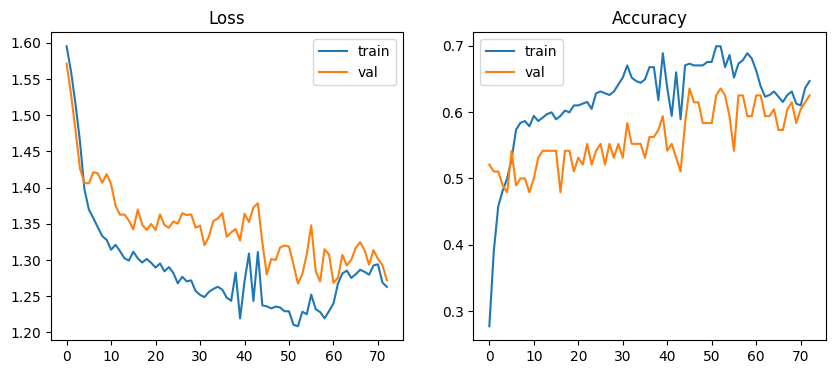

Test acc: 0.6354166865348816


In [18]:
# Plot curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist.history['loss'], label='train'); plt.plot(hist.history['val_loss'], label='val'); plt.title('Loss'); plt.legend();
plt.subplot(1,2,2); plt.plot(hist.history['accuracy'], label='train'); plt.plot(hist.history['val_accuracy'], label='val'); plt.title('Accuracy'); plt.legend();
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print('Test acc:', test_acc)


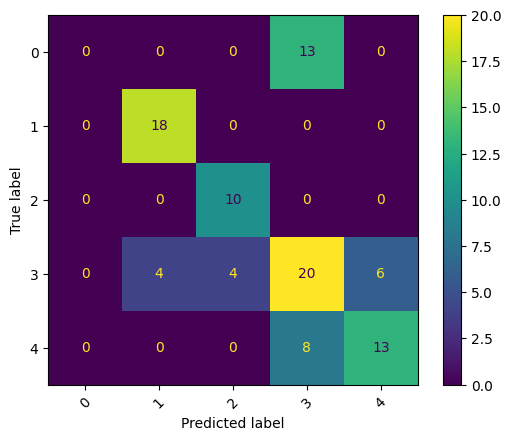

In [19]:
# (Optional) Confusion matrix
try:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(xticks_rotation=45)
except Exception as e:
    print('Confusion matrix skipped:', e)


In [20]:
# Export TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# 允许同时使用 TFLite 内置算子 + 一小部分 TensorFlow 原生算子（Select TF Ops）
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print('Saved TFLite to', TFLITE_PATH)


INFO:tensorflow:Assets written to: C:\Users\qichsun\AppData\Local\Temp\tmpho08sx2b\assets


INFO:tensorflow:Assets written to: C:\Users\qichsun\AppData\Local\Temp\tmpho08sx2b\assets


Saved TFLite to model/full_sequence_classifier\full_sequence_classifier.tflite


In [21]:
# Quick sanity check using TFLite interpreter
# (The actual runtime module also performs this.)
import numpy as np
try:
    from tensorflow.lite.python.interpreter import Interpreter
except Exception:
    import tflite_runtime.interpreter as tflite
    Interpreter = tflite.Interpreter

interpreter = Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_index = interpreter.get_input_details()[0]['index']
output_index = interpreter.get_output_details()[0]['index']

x0 = X_test[:1].astype('float32')
interpreter.set_tensor(input_index, x0)
interpreter.invoke()
y0 = interpreter.get_tensor(output_index)[0]
print('TFLite output:', y0, 'argmax=', int(np.argmax(y0)))


TFLite output: [1.5411616e-04 1.8801288e-04 1.9047682e-05 1.4532543e-02 9.8510635e-01] argmax= 4
